In [2]:
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.expanduser("~/notebooks/geospatial/"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
if module_path not in sys.path:
    print("$$$$$$$$")
    sys.path.append(module_path)

from sar.io import (
    crop_to_common_extent,
    raster_statistics,
    read_raster,
    same_extent,
)

from sar.filters.refined_lee import refined_lee_filter

from sar.plotting import (
    compare_images,
    show_difference,
    show_histogram,
    show_image,
)

$$$$$$$$


In [4]:
pre, pre_info = read_raster(
    "../tests/data/sample_image_preflood1.tif",
)

post, post_info = read_raster(
    "../tests/data/sample_image_postflood1.tif",
)

In [6]:
if not same_extent(pre_info, post_info):

    pre, post, info = crop_to_common_extent(
        pre,
        pre_info,
        post,
        post_info,
    )

else:

    info = pre_info

In [7]:
print(pre_info)
print(post_info)

RasterInfo(width=5071, height=5608, count=1, dtype='float64', crs=CRS.from_wkt('PROJCS["WGS 84 / UTM zone 46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",93],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32646"]]'), transform=Affine(10.0, 0.0, 299814.2863752869,
       0.0, -10.0, 2932617.729647672), nodata=None)
RasterInfo(width=5070, height=5607, count=1, dtype='float64', crs=CRS.from_wkt('PROJCS["WGS 84 / UTM zone 46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY[

In [8]:
print(f"Raster_Characterstics Pre - {raster_statistics(pre)}")
print(f"Raster_Characterstics Post -  {raster_statistics(post)}")

Raster_Characterstics Pre - RasterStatistics(minimum=-81.34020531664109, maximum=21.104377808521313, mean=-11.229968536113825, std=5.3951677566083305)
Raster_Characterstics Post -  RasterStatistics(minimum=-69.388551339966, maximum=29.161427867928786, mean=-13.536634275296919, std=7.114451934997773)


In [ ]:
show_image(
    pre,
    title="Pre-flood",
)

In [ ]:
show_image(
    post,
    title="Post-flood",
)

In [ ]:
show_histogram(pre)

In [ ]:
show_histogram(post)

In [ ]:
show_difference(
    pre,
    post,
)

In [ ]:
pre_filtered = refined_lee_filter(pre)

post_filtered = refined_lee_filter(post)

In [7]:
from sar.processing import apply_window_filter
from sar.filters.refined_lee import refined_lee_filter

pre_filtered = apply_window_filter(
    pre,
    refined_lee_filter,
    window_size=7,
)

In [8]:
post_filtered = apply_window_filter(
    post,
    refined_lee_filter,
    window_size=7,
)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Refined Lee'}>], dtype=object))

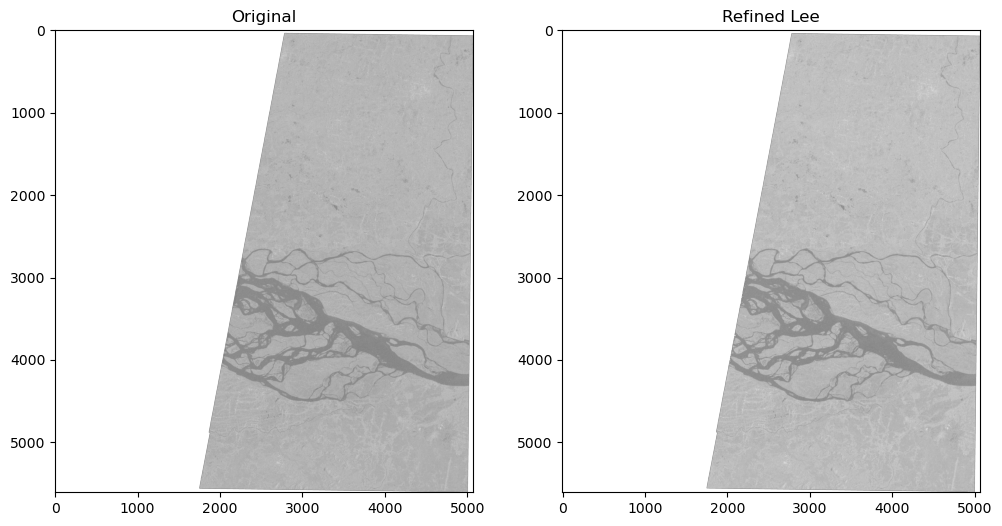

In [9]:
compare_images(
    pre,
    pre_filtered,
    title1="Original",
    title2="Refined Lee",
)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Refined Lee'}>], dtype=object))

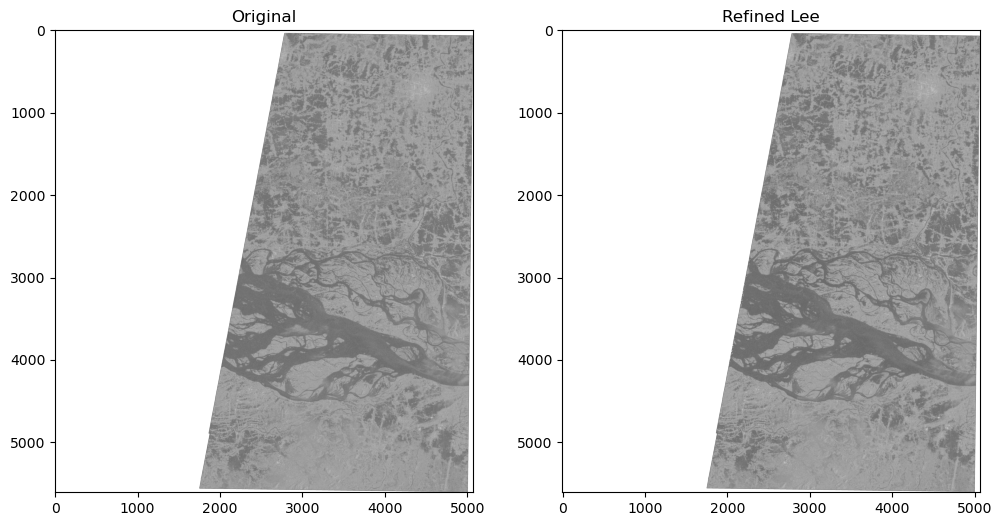

In [10]:
compare_images(
    post,
    post_filtered,
    title1="Original",
    title2="Refined Lee",
)

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'Difference'}>)

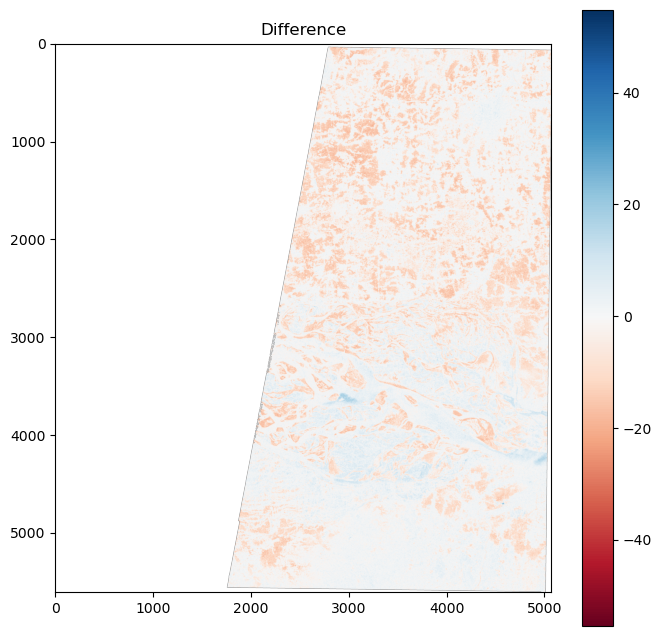

In [11]:
show_difference(
    pre_filtered,
    post_filtered,
)

(<Figure size 800x500 with 1 Axes>,
 <Axes: xlabel='Pixel value', ylabel='Frequency'>)

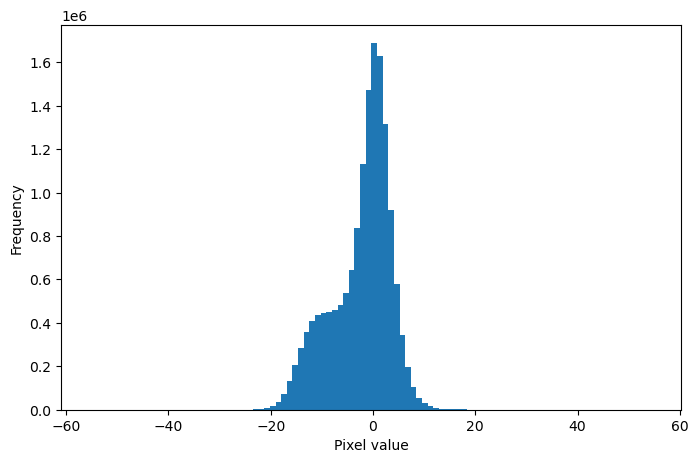

In [12]:
difference = post_filtered - pre_filtered

show_histogram(difference)

In [12]:

from sar.benchmarks.profiler import Profiler
from sar.processing import apply_window_filter
from sar.filters.refined_lee import refined_lee_filter_fast

with Profiler():

    filtered = apply_window_filter(
        image=pre,
        filter_function=refined_lee_filter_fast,
        window_size=7,
    )


Elapsed Time : 5729.87 seconds
         8439772139 function calls in 5729.871 seconds

   Ordered by: cumulative time
   List reduced from 69 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1   25.520   25.520 5729.871 5729.871 /home/ubuntu/notebooks/geospatial/sar/processing/window.py:6(apply_window_filter)
 28427490   80.276    0.000 5704.307    0.000 /home/ubuntu/notebooks/geospatial/sar/filters/refined_lee.py:690(refined_lee_filter_fast)
 28427490  247.475    0.000 4325.613    0.000 /home/ubuntu/notebooks/geospatial/sar/filters/refined_lee.py:662(_compute_subwindow_statistics)
284274900 1792.992    0.000 2991.026    0.000 /home/ubuntu/miniconda3/envs/geospatial/lib/python3.10/site-packages/numpy/_core/_methods.py:151(_var)
255847410   84.678    0.000 2780.886    0.000 {method 'var' of 'numpy.ndarray' objects}
312702390  525.067    0.000 1473.557    0.000 /home/ubuntu/miniconda3/envs/geospatial/lib/python3.10/site-packa